In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("kmeans_dataset.csv")
data = df.values
data


array([[ 2, 10],
       [ 2,  5],
       [ 8,  4],
       [ 5,  8],
       [ 7,  5],
       [ 6,  4],
       [ 1,  2],
       [ 4,  9]], dtype=int64)

In [3]:
k = 2

# choose first two points as initial centroids
centroids = data[:k]
centroids


array([[ 2, 10],
       [ 2,  5]], dtype=int64)

In [4]:
def distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))


In [5]:
for iteration in range(10):
    
    clusters = [[] for _ in range(k)]
    
    # assign points to nearest centroid
    for point in data:
        distances = [distance(point, c) for c in centroids]
        cluster_index = np.argmin(distances)
        clusters[cluster_index].append(point)
    
    # compute new centroids (MEAN FORMULA)
    new_centroids = []
    for cluster in clusters:
        new_centroids.append(np.mean(cluster, axis=0))
    
    new_centroids = np.array(new_centroids)
    
    # stop if centroids don't change
    if np.all(centroids == new_centroids):
        break
        
    centroids = new_centroids

centroids


array([[3.66666667, 9.        ],
       [4.8       , 4.        ]])

In [6]:
labels = []

for point in data:
    distances = [distance(point, c) for c in centroids]
    labels.append(np.argmin(distances))

df["Cluster"] = labels
df


,X,Y,Cluster
0,2,10,0
1,2,5,1
2,8,4,1
3,5,8,0
4,7,5,1
5,6,4,1
6,1,2,1
7,4,9,0


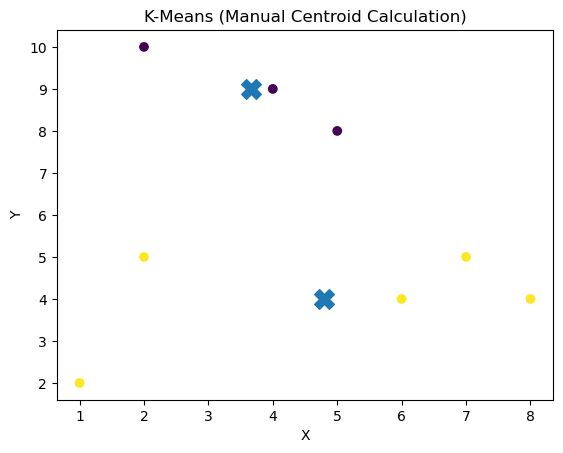

In [7]:
plt.scatter(df["X"], df["Y"], c=df["Cluster"])
plt.scatter(centroids[:,0], centroids[:,1], marker="X", s=200)

plt.title("K-Means (Manual Centroid Calculation)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
